In [2]:
import camb
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18

plt.style.use("specs5_farfield_style.mplstyle")

# You need files from Keir Rogers and Alma X. Gonzalez-Morales to run this notebook,
# which are not included in the repository. These might be added in the future.

# To be calculated using emulator forecasts
specs5_improvement_factor_amplitude_over_dr1 = 2.0
specs5_improvement_factor_slope_over_dr1 = 2.0

# DESI DR1 parameters for the compressed power-spectrum constraints at z=3
# Pivot redshift at which the compressed parameters are defined
# Citations: 2505.07974, 2601.21432 and 2505.09493
zstar= 3.0

kms2hMpc = 100.0 * Planck18.efunc(zstar) / (1 + zstar)

delta2star_mean= 0.379
delta2star_std= 0.032
nstar_mean= -2.309
nstar_std= 0.019

# Correlation coefficient between Delta^2_star and n_star
correlation= -0.1738

# Pivot scale in velocity units (km/s)
kstar_kms= 0.009
kstar_hMpc= kstar_kms * kms2hMpc  # Convert to h/Mpc
print(f"k_star = {kstar_hMpc:.2f} h/Mpc")

k_star = 1.02 h/Mpc


In [3]:
def getCambPlinear(zpivot=zstar):
    # Table 2 right-most column of Planck 2018 cosmological parameters
    ombh2 = 0.02242
    omch2= 0.11933
    mnu = 0.06
    h = 0.6766
    As = 2.105e-9
    ns = 0.9665
    tau = 0.0561

    camb_params = camb.set_params(
        redshifts=sorted([zpivot], reverse=True),
        WantCls=False, WantScalars=False,
        WantTensors=False, WantVectors=False,
        WantDerivedParameters=False,
        WantTransfer=True, kmax=2e2,
        omch2=omch2,
        ombh2=ombh2,
        omk=0.,
        H0=100.0 * h,
        ns=ns,
        As=As,
        mnu=mnu,
        tau=tau
    )
    camb_results = camb.get_results(camb_params)
    # Om = (ombh2 + omch2) / h**2
    # Or = camb_results.get_Omega('photon')

    camb_interp = camb_results.get_matter_power_interpolator(
        nonlinear=False, hubble_units=True, k_hunit=True)

    return camb_interp.P

In [4]:
camb_interp = getCambPlinear()

Text(0, 0.5, '$P_\\mathrm{lin} ~[h^{-3}\\mathrm{Mpc}^3]$')

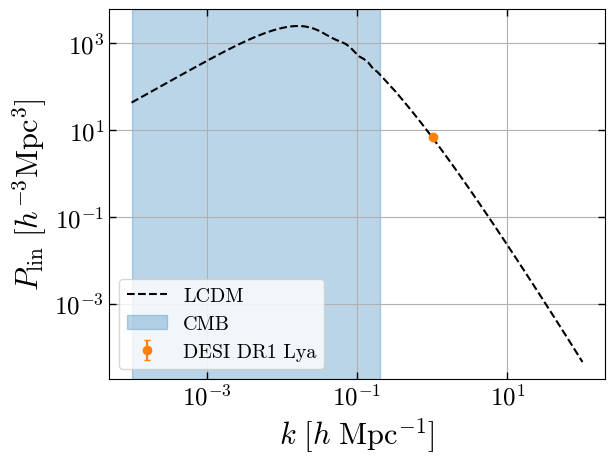

In [5]:
klin = np.geomspace(1e-4, 1e2, 100)
plt.loglog(klin, camb_interp(zstar, klin), 'k--', label="LCDM")
pstar_desi = delta2star_mean / kstar_hMpc**3 * (2 * np.pi**2)
epstar_desi = delta2star_std / kstar_hMpc**3 * (2 * np.pi**2)
plt.errorbar(kstar_hMpc, pstar_desi, yerr=epstar_desi, fmt='o', c=plt.cm.tab10(1),
             label='DESI DR1 Lya')

plt.axvspan(klin[0], 0.2, color=plt.cm.tab10(0), alpha=0.3, label='CMB')
plt.legend()

plt.xlabel(r'$k ~[h~\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P_\mathrm{lin} ~[h^{-3}\mathrm{Mpc}^3]$')

In [10]:
def getSlopePoints(npoints=100, nin=nstar_std, kout=np.geomspace(0.5, 2.0, 10)):
    """Draw random slope points from the distribution of n_star, and
    return the corresponding P(k) values at the given k_out."""
    sigma_n = np.random.default_rng().normal(loc=0, scale=nin, size=npoints)

    g = kout / kstar_hMpc
    return kout, g**sigma_n[:, None]


def getFiducialIGMSuppression(k_hMpc):
    Tfid = 1e4  # K
    BOLTZMANN_K = 8.617333262e-5  # eV / K
    M_PROTON = 0.938272088e9  # eV
    LIGHT_SPEED = 299792.458  # km/s
    sigma_fid = LIGHT_SPEED * np.sqrt(BOLTZMANN_K * Tfid / M_PROTON)
    print("Thermal broadening sigma (km/s):", sigma_fid)

    return np.exp(-k_hMpc**2 / kms2hMpc**2 * sigma_fid**2 / 2)


def readGutScaleAxionRatio():
    # GUT-scale axion from Keir's files
    kgut, pgut = np.loadtxt("../../../keir/test_SpecS5_matterpower_z1.dat", unpack=True)
    klcdm, plcdm = np.loadtxt("../../../keir/test_SpecS5_LCDM_matterpower_z1.dat", unpack=True)
    assert np.allclose(kgut, klcdm), "k values in the two files do not match"
    return kgut, pgut / plcdm


def readSFDMRatio():
    # SFDM from Alma
    from scipy.interpolate import CubicSpline
    dmmodel1_z0 = np.genfromtxt("../../../alma/sfdm_m23-00_pk.dat", skip_header=4)
    plin_z0 = np.genfromtxt("../../../alma/sfdm_m20-00_pk.dat", skip_header=4)
    plin_z0 = CubicSpline(np.log(plin_z0[:, 0]), np.log(plin_z0[:, 1]))
    ksf = dmmodel1_z0[:, 0]
    ratio = dmmodel1_z0[:, 1] / np.exp(plin_z0(np.log(dmmodel1_z0[:, 0])))
    return ksf, ratio


def getRunningDeviation(
        k_hMpc=np.geomspace(1e-3, 1e2, 200), alpha_s=-0.0045,
        kprimo_iMpc=0.05, h=0.6766
):
    kprimo_hMpc = kprimo_iMpc / h  # Convert to h/Mpc
    r = k_hMpc / kprimo_hMpc
    return k_hMpc, r**(0.5 * alpha_s * np.log(r))

Planck prediction for Delta^2_star at k=1.0217 h/Mpc: 0.348


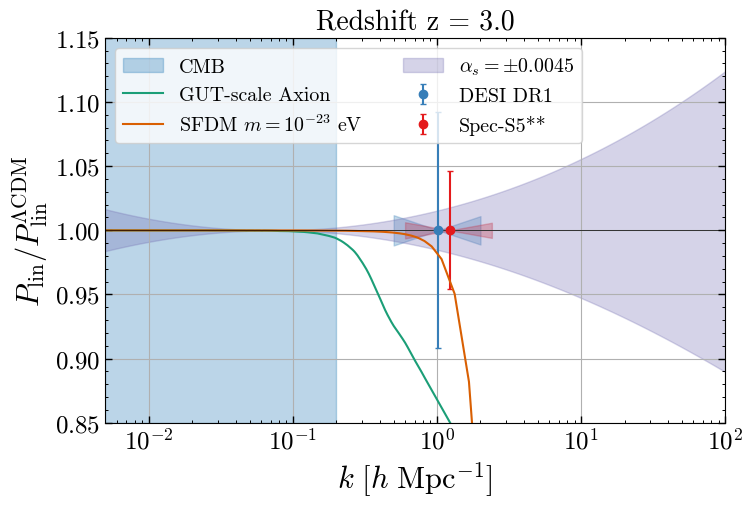

In [11]:
# as ratio
plt.figure(figsize=(8, 5))
klin = np.geomspace(5e-3, 1e2, 100)
# plt.plot(klin, np.ones_like(klin), 'k-', label="LCDM")
plt.axvspan(klin[0], 0.2, color=plt.cm.tab10(0), alpha=0.3, label='CMB')

planck_delta2_star = kstar_hMpc**3 * camb_interp(zstar, kstar_hMpc) / (2 * np.pi**2)
print(f"Planck prediction for Delta^2_star at k={kstar_hMpc:.4f} h/Mpc: {planck_delta2_star:.3f}")


plt.errorbar(kstar_hMpc, 1.0, yerr=delta2star_std / planck_delta2_star,
             fmt='o', c=plt.cm.Set1(1), label='DESI DR1')

kout, slopes = getSlopePoints(nin=nstar_std)
slopes = np.std(slopes, axis=0)
plt.fill_between(kout, 1.0 - slopes, 1.0 + slopes, color=plt.cm.Set1(1), alpha=0.3)


plt.errorbar(kstar_hMpc *1.2, 1.0, yerr=delta2star_std / planck_delta2_star / specs5_improvement_factor_amplitude_over_dr1,
             fmt='o', c=plt.cm.Set1(0), label='Spec-S5**')
kout, slopes = getSlopePoints(nin=nstar_std/specs5_improvement_factor_slope_over_dr1)
slopes = np.std(slopes, axis=0)
plt.fill_between(kout *1.2, 1.0 - slopes, 1.0 + slopes, color=plt.cm.Set1(0), alpha=0.3)

plt.plot(*readGutScaleAxionRatio(), c=plt.cm.Dark2(0), ls='-', label=r"GUT-scale Axion")
plt.plot(*readSFDMRatio(), c=plt.cm.Dark2(1), ls='-', label=r"SFDM $m=10^{-23}$ eV")
alpha_s = 0.0045
ka, rl = getRunningDeviation(alpha_s=-alpha_s)
ka, ru = getRunningDeviation(alpha_s=alpha_s)
plt.fill_between(ka, rl, ru, color=plt.cm.Dark2(2), alpha=0.3, label=rf"$\alpha_s=\pm {alpha_s:.4f}$")

# plt.plot(*getRunningDeviation(), c=plt.cm.Dark2(2), ls='-', label=r"$\alpha_s=-0.0045$")
# plt.plot(klin, getFiducialIGMSuppression(klin), c='grey', ls='--', label=r'Thermal suppression ($T=10^4$ K)')


# plt.axvline(desi_kmax, color='red', ls='--', label='Realistic DESI resolution limit')
plt.legend(loc="upper left", ncol=2)
plt.xscale("log")
plt.xlabel(r'$k ~[h~\mathrm{Mpc}^{-1}]$')
# plt.ylabel(r'$P_\mathrm{lin} / P_\mathrm{lin}^\mathrm{Planck}$')
plt.ylabel(r'$P_\mathrm{lin} / P_\mathrm{lin}^{\Lambda\mathrm{CDM}}$')
plt.title(f"Redshift z = {zstar:.1f}")
plt.xlim(klin[0], klin[-1])
plt.ylim(0.85, 1.15)
plt.axhline(1.0, color='k', ls='-', lw=0.5)

plt.show()